# Homework — Part 2: Training Neural Networks with Custom Modules

**Содержание:**
1. Оптимизаторы (SGD + momentum, Adam)
2. LR-scheduler (cosine, step) + warmup + early stopping
3. Регрессия (synthetic, multi-target, 3 размера модели, 5 активаций)
4. Классификация (MNIST с fallback на load_digits)
5. Автоэнкодер (свёрточный, с быстрым конфигом под датасет)

> **Датасеты:** синтетические и sklearn/openml. Если MNIST недоступен в среде запуска, ноутбук автоматически переключается на `load_digits`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from sklearn.datasets import make_regression, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')
np.random.seed(42) 
import pathlib
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


## Часть 1 — Слои, активации и критерии (из homework_modules)

Я тут не стал импортить через библиотеку

In [2]:
class Module:
    def __init__(self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, x):
        return self.updateOutput(x)

    def backward(self, x, g):
        self.updateGradInput(x, g)
        self.accGradParameters(x, g)
        return self.gradInput

    def updateOutput(self, x):
        pass

    def updateGradInput(self, x, g):
        pass

    def accGradParameters(self, x, g):
        pass

    def zeroGradParameters(self):
        pass

    def getParameters(self):
        return []

    def getGradParameters(self):
        return []

    def train(self):
        self.training = True

    def evaluate(self):
        self.training = False

class Sequential(Module):
    def __init__(self):
        super().__init__()
        self.modules = []
        self._ins = []

    def add(self, m):
        self.modules.append(m)
        return self

    def updateOutput(self, x):
        self._ins = [x]
        cur = x
        for m in self.modules:
            cur = m.forward(cur)
            self._ins.append(cur)
        self.output = cur
        return cur

    def backward(self, x, g):
        for i in range(len(self.modules) - 1, -1, -1):
            g = self.modules[i].backward(self._ins[i], g)
        self.gradInput = g
        return g

    def zeroGradParameters(self):
        for m in self.modules:
            m.zeroGradParameters()

    def getParameters(self):
        params = []
        for m in self.modules:
            params.extend(m.getParameters())
        return params

    def getGradParameters(self):
        grad_params = []
        for m in self.modules:
            grad_params.extend(m.getGradParameters())
        return grad_params

    def train(self):
        self.training = True
        for m in self.modules:
            m.train()

    def evaluate(self):
        self.training = False
        for m in self.modules:
            m.evaluate()

class Linear(Module):
    def __init__(self, ni, no):
        super().__init__()
        s = 1.0 / np.sqrt(ni)
        self.W = np.random.uniform(-s, s, (no, ni)).astype(np.float32)
        self.b = np.random.uniform(-s, s, no).astype(np.float32)
        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, x):
        self.output = x @ self.W.T + self.b
        return self.output

    def updateGradInput(self, x, g):
        self.gradInput = g @ self.W
        return self.gradInput

    def accGradParameters(self, x, g):
        self.gradW = g.T @ x
        self.gradb = g.sum(axis=0)

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        return f"Linear({self.W.shape[1]}->{self.W.shape[0]})"

class BatchNormalization(Module):
    EPS = 1e-3

    def __init__(self, alpha=0.):
        super().__init__()
        self.alpha = alpha
        self.mu = None
        self.var = None
        self._mean = None
        self._var = None
        self._std = None

    def updateOutput(self, x):
        if self.training:
            bm = x.mean(axis=0)
            bv = x.var(axis=0)
            if self.mu is None:
                self.mu = bm.copy()
                self.var = bv.copy()
            else:
                self.mu = self.alpha * self.mu + (1 - self.alpha) * bm
                self.var = self.alpha * self.var + (1 - self.alpha) * bv
            self._mean = bm
            self._var = bv
        else:
            if self.mu is None:
                self._mean = x.mean(axis=0)
                self._var = x.var(axis=0)
            else:
                self._mean = self.mu
                self._var = self.var
        self._std = np.sqrt(self._var + self.EPS)
        self.output = (x - self._mean) / self._std
        return self.output

    def updateGradInput(self, x, g):
        if not self.training:
            self.gradInput = g / self._std
            return self.gradInput
        N = x.shape[0]
        xh = (x - self._mean) / self._std
        self.gradInput = (N * g - g.sum(axis=0) - xh * (g * xh).sum(axis=0)) / (N * self._std)
        return self.gradInput

class ChannelwiseScaling(Module):
    def __init__(self, n):
        super().__init__()
        s = 1.0 / np.sqrt(n)
        self.gamma = np.random.uniform(-s, s, n).astype(np.float32)
        self.beta = np.random.uniform(-s, s, n).astype(np.float32)
        self.dg = np.zeros(n, np.float32)
        self.db = np.zeros(n, np.float32)

    def updateOutput(self, x):
        self.output = x * self.gamma + self.beta
        return self.output

    def updateGradInput(self, x, g):
        self.gradInput = g * self.gamma
        return self.gradInput

    def accGradParameters(self, x, g):
        self.db = g.sum(axis=0)
        self.dg = (g * x).sum(axis=0)

    def zeroGradParameters(self):
        self.dg.fill(0)
        self.db.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.dg, self.db]

class Dropout(Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p
        self.mask = None

    def updateOutput(self, x):
        if self.training:
            self.mask = (np.random.rand(*x.shape) > self.p).astype(x.dtype)
            self.output = x * self.mask / (1 - self.p)
        else:
            self.output = x.copy()
        return self.output

    def updateGradInput(self, x, g):
        self.gradInput = g * self.mask / (1 - self.p) if self.training else g.copy()
        return self.gradInput

class ReLU(Module):
    def updateOutput(self, x):
        self.output = np.maximum(x, 0)
        return self.output

    def updateGradInput(self, x, g):
        self.gradInput = g * (x > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

class LeakyReLU(Module):
    def __init__(self, s=0.03):
        super().__init__()
        self.s = s

    def updateOutput(self, x):
        self.output = np.where(x >= 0, x, self.s * x)
        return self.output

    def updateGradInput(self, x, g):
        self.gradInput = g * np.where(x >= 0, 1.0, self.s)
        return self.gradInput

class ELU(Module):
    def __init__(self, a=1.0):
        super().__init__()
        self.a = a

    def updateOutput(self, x):
        self.output = np.where(x >= 0, x, self.a * (np.exp(x) - 1))
        return self.output

    def updateGradInput(self, x, g):
        self.gradInput = g * np.where(x >= 0, 1.0, self.a * np.exp(x))
        return self.gradInput

class Gelu(Module):
    def updateOutput(self, x):
        self.output = x * 0.5 * (1 + erf(x / np.sqrt(2)))
        return self.output

    def updateGradInput(self, x, g):
        P = 0.5 * (1 + erf(x / np.sqrt(2)))
        ph = np.exp(-0.5 * x ** 2) / np.sqrt(2 * np.pi)
        self.gradInput = g * (P + x * ph)
        return self.gradInput

class SoftPlus(Module):
    def updateOutput(self, x):
        self.output = np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)
        return self.output

    def updateGradInput(self, x, g):
        self.gradInput = g / (1 + np.exp(-x))
        return self.gradInput

class Sigmoid(Module):
    def updateOutput(self, x):
        self.output = 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))
        return self.output

    def updateGradInput(self, x, g):
        s = self.output
        self.gradInput = g * s * (1 - s)
        return self.gradInput

class LogSoftMax(Module):
    def updateOutput(self, x):
        s = x - x.max(axis=1, keepdims=True)
        self.output = s - np.log(np.exp(s).sum(axis=1, keepdims=True))
        return self.output

    def updateGradInput(self, x, g):
        sm = np.exp(self.output)
        self.gradInput = g - sm * g.sum(axis=1, keepdims=True)
        return self.gradInput

class Conv2d(Module):
    def __init__(self, ci, co, ks, stride=1, padding=0, bias=True, padding_mode='zeros'):
        super().__init__()
        self.ci = ci
        self.co = co
        self.ks = (ks, ks) if isinstance(ks, int) else ks
        self.st = (stride, stride) if isinstance(stride, int) else stride
        self.pd = (padding, padding) if isinstance(padding, int) else padding
        self.use_bias = bias
        self.padding_mode = padding_mode

        kH, kW = self.ks
        s = 1.0 / np.sqrt(ci * kH * kW)
        self.weight = np.random.uniform(-s, s, (co, ci, kH, kW)).astype(np.float32)
        self.bias = np.random.uniform(-s, s, co).astype(np.float32) if bias else None
        self.dW = np.zeros_like(self.weight)
        self.db = np.zeros_like(self.bias) if bias else None
        self._cols = None

    def _pad_input(self, x):
        pH, pW = self.pd
        if pH == 0 and pW == 0:
            return x
        if self.padding_mode == 'zeros':
            return np.pad(x, ((0, 0), (0, 0), (pH, pH), (pW, pW)), mode='constant')
        if self.padding_mode == 'reflect':
            return np.pad(x, ((0, 0), (0, 0), (pH, pH), (pW, pW)), mode='reflect')
        if self.padding_mode == 'replicate':
            return np.pad(x, ((0, 0), (0, 0), (pH, pH), (pW, pW)), mode='edge')
        if self.padding_mode == 'circular':
            return np.pad(x, ((0, 0), (0, 0), (pH, pH), (pW, pW)), mode='wrap')
        raise ValueError('Unsupported padding_mode: {}'.format(self.padding_mode))

    def _pad_indices(self, size, pad):
        idx = np.arange(size, dtype=np.int64)
        if pad == 0:
            return idx
        if self.padding_mode == 'reflect':
            return np.pad(idx, (pad, pad), mode='reflect')
        if self.padding_mode == 'replicate':
            return np.pad(idx, (pad, pad), mode='edge')
        if self.padding_mode == 'circular':
            return np.pad(idx, (pad, pad), mode='wrap')
        raise ValueError('Unsupported padding_mode: {}'.format(self.padding_mode))

    def _im2col(self, xp, kH, kW, sH, sW, oH, oW):
        N, C, _, _ = xp.shape
        col = np.zeros((N, oH * oW, C * kH * kW), dtype=xp.dtype)
        for i in range(oH):
            for j in range(oW):
                patch = xp[:, :, i * sH:i * sH + kH, j * sW:j * sW + kW]
                col[:, i * oW + j, :] = patch.reshape(N, -1)
        return col

    def _col2im(self, dc, N, C, H, W, kH, kW, sH, sW, pH, pW, oH, oW):
        dx = np.zeros((N, C, H + 2 * pH, W + 2 * pW), dtype=dc.dtype)
        for i in range(oH):
            for j in range(oW):
                dx[:, :, i * sH:i * sH + kH, j * sW:j * sW + kW] += dc[:, :, i * oW + j].reshape(N, C, kH, kW)
        return dx

    def _unpad_grad(self, dx, H, W):
        pH, pW = self.pd
        if pH == 0 and pW == 0:
            return dx
        if self.padding_mode == 'zeros':
            return dx[:, :, pH:pH + H, pW:pW + W]

        idx_h = self._pad_indices(H, pH)
        idx_w = self._pad_indices(W, pW)
        grad = np.zeros((dx.shape[0], dx.shape[1], H, W), dtype=dx.dtype)
        for i_pad, i_src in enumerate(idx_h):
            for j_pad, j_src in enumerate(idx_w):
                grad[:, :, i_src, j_src] += dx[:, :, i_pad, j_pad]
        return grad

    def updateOutput(self, x):
        N, Ci, H, W = x.shape
        kH, kW = self.ks
        sH, sW = self.st
        pH, pW = self.pd

        xp = self._pad_input(x)
        oH = (H + 2 * pH - kH) // sH + 1
        oW = (W + 2 * pW - kW) // sW + 1
        self._cols = self._im2col(xp, kH, kW, sH, sW, oH, oW)

        Wm = self.weight.reshape(self.co, -1)
        out = self._cols @ Wm.T
        out = out.transpose(0, 2, 1).reshape(N, self.co, oH, oW)
        if self.use_bias:
            out = out + self.bias[None, :, None, None]
        self.output = out
        return out

    def updateGradInput(self, x, g):
        N, Ci, H, W = x.shape
        kH, kW = self.ks
        sH, sW = self.st
        pH, pW = self.pd
        oH, oW = g.shape[2], g.shape[3]

        Wm = self.weight.reshape(self.co, -1)
        go = g.reshape(N, self.co, oH * oW)
        dc = np.tensordot(Wm.T, go, axes=([1], [1])).transpose(1, 0, 2)
        dx = self._col2im(dc, N, Ci, H, W, kH, kW, sH, sW, pH, pW, oH, oW)
        self.gradInput = self._unpad_grad(dx, H, W)
        return self.gradInput

    def accGradParameters(self, x, g):
        kH, kW = self.ks
        go = g.transpose(0, 2, 3, 1).reshape(-1, self.co)
        cols = self._cols.reshape(-1, self.ci * kH * kW)
        self.dW = (go.T @ cols).reshape(self.weight.shape)
        if self.use_bias:
            self.db = g.sum(axis=(0, 2, 3))

    def zeroGradParameters(self):
        self.dW.fill(0)
        if self.use_bias:
            self.db.fill(0)

    def getParameters(self):
        if self.use_bias:
            return [self.weight, self.bias]
        return [self.weight]

    def getGradParameters(self):
        if self.use_bias:
            return [self.dW, self.db]
        return [self.dW]

class MaxPool2d(Module):
    def __init__(self, k, s, p=0):
        super().__init__()
        self.k = k
        self.s = s
        self.p = p

    def updateOutput(self, x):
        N, C, H, W = x.shape
        k, s, p = self.k, self.s, self.p
        xp = np.pad(x, ((0, 0), (0, 0), (p, p), (p, p)), constant_values=-np.inf) if p else x
        oH = (H + 2 * p - k) // s + 1
        oW = (W + 2 * p - k) // s + 1
        self.output = np.zeros((N, C, oH, oW), dtype=x.dtype)
        for i in range(oH):
            for j in range(oW):
                self.output[:, :, i, j] = xp[:, :, i * s:i * s + k, j * s:j * s + k].max(axis=(-2, -1))
        return self.output

    def updateGradInput(self, x, g):
        N, C, H, W = x.shape
        k, s, p = self.k, self.s, self.p
        oH, oW = g.shape[2], g.shape[3]
        xp = np.pad(x, ((0, 0), (0, 0), (p, p), (p, p)), constant_values=-np.inf) if p else x
        dx = np.zeros_like(xp)
        for i in range(oH):
            for j in range(oW):
                pt = xp[:, :, i * s:i * s + k, j * s:j * s + k]
                mv = pt.max(axis=(-2, -1), keepdims=True)
                mask = (pt == mv).astype(float)
                mask /= mask.sum(axis=(-2, -1), keepdims=True)
                dx[:, :, i * s:i * s + k, j * s:j * s + k] += mask * g[:, :, i:i + 1, j:j + 1]
        self.gradInput = dx[:, :, p:p + H, p:p + W] if p else dx
        return self.gradInput

class Flatten(Module):
    def __init__(self, start_dim=1, end_dim=-1):
        super().__init__()
        self.start_dim = start_dim
        self.end_dim = end_dim

    def updateOutput(self, x):
        nd = x.ndim
        start = self.start_dim if self.start_dim >= 0 else nd + self.start_dim
        end = self.end_dim if self.end_dim >= 0 else nd + self.end_dim
        if start > end:
            raise ValueError('start_dim must be <= end_dim')
        flat_dim = int(np.prod(x.shape[start:end + 1]))
        self.output = x.reshape(x.shape[:start] + (flat_dim,) + x.shape[end + 1:])
        return self.output

    def updateGradInput(self, x, g):
        self.gradInput = g.reshape(x.shape)
        return self.gradInput

class Upsample2d(Module):
    def __init__(self, sc=2):
        super().__init__()
        self.sc = sc

    def updateOutput(self, x):
        self.output = np.repeat(np.repeat(x, self.sc, axis=-1), self.sc, axis=-2)
        return self.output

    def updateGradInput(self, x, g):
        N, C, H, W = x.shape
        sc = self.sc
        self.gradInput = g.reshape(N, C, H, sc, W, sc).sum(axis=(3, 5))
        return self.gradInput

class Reshape(Module):
    def __init__(self, *sh):
        super().__init__()
        self.sh = sh

    def updateOutput(self, x):
        self._in = x.shape
        self.output = x.reshape((x.shape[0],) + self.sh)
        return self.output

    def updateGradInput(self, x, g):
        self.gradInput = g.reshape(self._in)
        return self.gradInput

class Criterion:
    def __init__(self):
        self.output = None
        self.gradInput = None

    def forward(self, i, t):
        return self.updateOutput(i, t)

    def backward(self, i, t):
        return self.updateGradInput(i, t)

    def updateOutput(self, i, t):
        return self.output

    def updateGradInput(self, i, t):
        return self.gradInput

class MSECriterion(Criterion):
    def updateOutput(self, i, t):
        self.output = float(np.sum((i - t) ** 2) / i.shape[0])
        return self.output

    def updateGradInput(self, i, t):
        self.gradInput = 2 * (i - t) / i.shape[0]
        return self.gradInput

class MSE4D(Criterion):
    """MSE для произвольных тензоров (используется в автоэнкодере)."""
    def updateOutput(self, i, t):
        self.output = float(np.mean((i - t) ** 2))
        return self.output

    def updateGradInput(self, i, t):
        self.gradInput = 2 * (i - t) / i.size
        return self.gradInput

class MAECriterion(Criterion):
    def updateOutput(self, i, t):
        self.output = float(np.mean(np.abs(i - t)))
        return self.output

    def updateGradInput(self, i, t):
        self.gradInput = np.sign(i - t) / i.size
        return self.gradInput

class ClassNLLCriterion(Criterion):
    def updateOutput(self, i, t):
        self.output = -float(np.sum(t * i) / i.shape[0])
        return self.output

    def updateGradInput(self, i, t):
        self.gradInput = -t / i.shape[0]
        return self.gradInput

        return self.gradInput


## 1. Оптимизаторы

Реализованы **SGD с моментумом** и **Adam** — оба работают с любым `Sequential`-моделью через
`model.getParameters()` / `model.getGradParameters()`.
Поддерживают `set_lr()` для планировщиков.

In [3]:
def _flat(lst):
    out=[]
    for x in lst:
        if isinstance(x,list): out.extend(_flat(x))
        elif isinstance(x,np.ndarray): out.append(x)
    return out

class SGD:
    def __init__(self, m, lr=0.01, momentum=0.9, wd=0.):
        self.m=m; self.lr=lr; self.mu=momentum; self.wd=wd; self._v=None
    def step(self):
        P,G=_flat(self.m.getParameters()),_flat(self.m.getGradParameters())
        if self._v is None: self._v=[np.zeros_like(p) for p in P]
        for p,g,v in zip(P,G,self._v):
            v*=self.mu; v+=self.lr*(g+self.wd*p if self.wd else g); p-=v
    def zero_grad(self): self.m.zeroGradParameters()
    def set_lr(self, lr): self.lr=lr

class Adam:
    def __init__(self, m, lr=1e-3, betas=(0.9,0.999), eps=1e-8, wd=0.):
        self.m=m; self.lr=lr; self.b1,self.b2=betas; self.eps=eps; self.wd=wd
        self._mm=None; self._v=None; self._t=0
    def step(self):
        P,G=_flat(self.m.getParameters()),_flat(self.m.getGradParameters())
        if self._mm is None: self._mm=[np.zeros_like(p) for p in P]; self._v=[np.zeros_like(p) for p in P]
        self._t+=1; lt=self.lr*np.sqrt(1-self.b2**self._t)/(1-self.b1**self._t) 
        for p,g,m,v in zip(P,G,self._mm,self._v):
            ge=g+self.wd*p if self.wd else g
            m*=self.b1; m+=(1-self.b1)*ge; v*=self.b2; v+=(1-self.b2)*ge*ge
            p-=lt*m/(np.sqrt(v)+self.eps)
    def zero_grad(self): self.m.zeroGradParameters()
    def set_lr(self, lr): self.lr=lr

## 2. LR-Scheduler, Warmup, Early Stopping, Trainer

`Trainer` инкапсулирует весь обучающий цикл:
- **Warmup** — линейный разогрев LR в первые `warmup` эпох  
- **Scheduler** — cosine annealing (или step decay) после разогрева  
- **Early stopping** — остановка при отсутствии улучшения за `patience` эпох  
- **Сохранение лучшей модели** — восстанавливает лучшие веса после обучения  
- **Switch**: принимает любой критерий, оптимизатор и метрику как параметры

In [4]:
def cosine_lr(base, ep, total, eta_min=1e-6):
    return eta_min+0.5*(base-eta_min)*(1+np.cos(np.pi*ep/max(total,1)))

def step_lr(base, ep, step=5, gamma=0.5):
    return base*(gamma**(ep//step))

def r2_score(pred, target):
    ss_res = np.sum((target - pred) ** 2)
    ss_tot = np.sum((target - target.mean(axis=0, keepdims=True)) ** 2)
    return float(1.0 - ss_res / max(ss_tot, 1e-12))

def save_checkpoint(path, model):
    import pathlib
    pathlib.Path(path).parent.mkdir(parents=True, exist_ok=True)
    flat = []
    def rec(p):
        if isinstance(p, list):
            for x in p: rec(x)
        else:
            flat.append(np.copy(p))
    rec(model.getParameters())
    np.savez_compressed(str(path), *flat)

def load_checkpoint(path, model):
    z = np.load(path)
    flat = [z[k] for k in sorted(z.files, key=lambda name: int(name.split('_')[1]))]
    it = iter(flat)
    def rec(p):
        if isinstance(p, list):
            for x in p: rec(x)
        else:
            p[...] = next(it)
    rec(model.getParameters())

class Trainer:
    def __init__(self, model, crit, opt, metric_fn=None, sched=None,
                 checkpoint_path=None):
        self.model=model; self.crit=crit; self.opt=opt
        self.mfn=metric_fn; self.sched=sched
        self.checkpoint_path=checkpoint_path
        self.tl=[]; self.vl=[]; self.tm=[]; self.vm=[]
        self.best=np.inf; self._bw=None; self._pat=0  # pat = счётчик плохих эпох

    def _run(self, X, y, bs, train):
        n=X.shape[0]; idx=np.random.permutation(n) if train else np.arange(n)
        ls=[]; ms=[]
        for s in range(0,n,bs):
            bi=idx[s:s+bs]; xb,yb=X[bi],y[bi]
            p=self.model.forward(xb)
            ls.append(float(self.crit.forward(p,yb)))
            if self.mfn: ms.append(float(self.mfn(p,yb)))
            if train:
                self.opt.zero_grad()
                self.model.backward(xb,self.crit.backward(p,yb))
                self.opt.step()
        return np.mean(ls),(np.mean(ms) if ms else None)

    def fit(self, Xt,yt,Xv,yv, epochs=50,bs=64,patience=10,warmup=3,
            lr=None, min_delta=0.0, verbose=True):
        lr=lr or self.opt.lr
        for ep in range(1,epochs+1):
            if ep<=warmup: cur=lr*ep/warmup
            elif self.sched: cur=self.sched(lr,ep-warmup,epochs-warmup)
            else: cur=lr
            self.opt.set_lr(cur)
            self.model.train(); tl,tm=self._run(Xt,yt,bs,True)
            self.model.evaluate(); vl,vm=self._run(Xv,yv,bs,False)
            self.tl.append(tl); self.vl.append(vl)
            if tm is not None: self.tm.append(tm); self.vm.append(vm)
            if vl < self.best - min_delta:
                self.best=vl
                self._bw=[p.copy() for p in _flat(self.model.getParameters())]
                if self.checkpoint_path:
                    save_checkpoint(self.checkpoint_path, self.model)
                self._pat=0
            else: self._pat+=1
            if verbose and ep%max(1,epochs//8)==0:
                s=f"  ep{ep:3}/{epochs} lr={cur:.1e} | tr={tl:.4f} vl={vl:.4f}"
                if vm is not None: s+=f" | metric={vm:.4f}"
                print(s)
            if self._pat>=patience:
                verbose and print(f"  early stop @ ep{ep}"); break
        # Восстанавливаем лучшие веса
        if self._bw:
            for p,w in zip(_flat(self.model.getParameters()),self._bw): p[:]=w

    def plot(self, title="", mname="Metric", path=None):
        has=bool(self.tm); fig,axs=plt.subplots(1,2 if has else 1,figsize=(12,4))
        if not has: axs=[axs]
        axs[0].plot(self.tl,'b',label='train'); axs[0].plot(self.vl,'r',label='val')
        axs[0].set(title=f'{title} Loss',xlabel='Epoch'); axs[0].legend(); axs[0].grid()
        if has:
            axs[1].plot(self.tm,'b',label='train'); axs[1].plot(self.vm,'r',label='val')
            axs[1].set(title=f'{title} {mname}',xlabel='Epoch'); axs[1].legend(); axs[1].grid()
        plt.tight_layout()
        if path: plt.savefig(path,dpi=90)
        plt.show()


## 3. Мультирегрессия (3 целевых переменных, 15 фичей)

**Датасет:** `sklearn.make_regression` — синтетический, 10 информативных признаков из 15, шум σ=15.  
**Лосс:** MSECriterion (+ сравнение с MAE)  
**Метрика:** RMSE на тест-сете  
**Архитектура:** FCNN + BatchNorm + ChannelwiseScaling + Dropout  
**Режим:** компактный конфиг, чтобы ноутбук не выполнялся слишком долго

In [5]:
CKPT_DIR = pathlib.Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)  # папка для чекпоинтов

X,Y=make_regression(4000,15,n_informative=10,n_targets=3,noise=15.,random_state=42)
X,Y=X.astype(np.float32),Y.astype(np.float32)
Xt,Xv,Yt,Yv=train_test_split(X,Y,test_size=0.2,random_state=0)
Xv,Xte,Yv,Yte=train_test_split(Xv,Yv,test_size=0.5,random_state=0)
sx,sy=StandardScaler(),StandardScaler()
Xt=sx.fit_transform(Xt).astype(np.float32); Xv=sx.transform(Xv).astype(np.float32); Xte=sx.transform(Xte).astype(np.float32)
Yt=sy.fit_transform(Yt).astype(np.float32); Yv=sy.transform(Yv).astype(np.float32); Yte=sy.transform(Yte).astype(np.float32)

def rmse(p,t): return float(np.sqrt(np.mean((p-t)**2)))

def build_reg(hs, Act=ReLU):
    m=Sequential(); d=15
    for h in hs:
        m.add(Linear(d,h)).add(BatchNormalization(0.9)).add(ChannelwiseScaling(h))
        m.add(Act()).add(Dropout(0.2)); d=h
    return m.add(Linear(d,3))

reg_main_epochs = 18
reg_main_bs = 512
reg_main_patience = 4
reg_cmp_epochs = 12
reg_cmp_bs = 512
reg_cmp_patience = 3
reg_fast_opt = dict(lr=0.05, momentum=0.9)

# три размера: смотрим есть ли overfitting на big и underfitting на small
trainers_sz = {}
for name,hs in [('big',[256,128,64]),('medium',[64,32]),('small',[16])]:
    np.random.seed(42)
    mdl=build_reg(hs)
    tr=Trainer(mdl, MSECriterion(), SGD(mdl,**reg_fast_opt), rmse, cosine_lr,
               checkpoint_path=CKPT_DIR/f"reg_{name}.npz")
    tr.fit(Xt,Yt,Xv,Yv,epochs=reg_main_epochs,bs=reg_main_bs,
           patience=reg_main_patience,warmup=2,lr=reg_fast_opt['lr'],verbose=False)
    mdl.evaluate()
    pred_te = mdl.forward(Xte)
    r = rmse(pred_te, Yte)
    r2 = r2_score(pred_te, Yte)
    print(f"  {name:8s} | test RMSE={r:.4f}  R²={r2:.4f}  ckpt=reg_{name}.npz")
    if r2 < 0.5:
        print(f"    !! R² низкий для {name} — возможно underfitting или плохие гиперпараметры")
    trainers_sz[name] = tr

# сравнение активаций делаем только для нескольких базовых вариантов,
# чтобы ноутбук оставался компактным по времени.
print()
for an,Ac in [('ReLU',ReLU),('ELU',ELU),('Gelu',Gelu)]:
    np.random.seed(42); mdl=build_reg([64,32],Ac)
    tr=Trainer(mdl,MSECriterion(),SGD(mdl,**reg_fast_opt),rmse,cosine_lr)
    tr.fit(Xt,Yt,Xv,Yv,epochs=reg_cmp_epochs,bs=reg_cmp_bs,
           patience=reg_cmp_patience,warmup=2,lr=reg_fast_opt['lr'],verbose=False)
    mdl.evaluate()
    pred_te = mdl.forward(Xte)
    print(f"  Act={an:10s} | RMSE={rmse(pred_te,Yte):.4f}  R²={r2_score(pred_te,Yte):.4f}")

# сравниваем Adam vs SGD — на этом примере видно, кто быстрее выходит на хороший минимум
print()
for on,of,kw in [('Adam',Adam,dict(lr=1e-3)),('SGD',SGD,dict(lr=0.05,momentum=0.9))]:
    np.random.seed(42); mdl=build_reg([64,32]); opt=of(mdl,**kw)
    tr=Trainer(mdl,MSECriterion(),opt,rmse,cosine_lr)
    tr.fit(Xt,Yt,Xv,Yv,epochs=reg_cmp_epochs,bs=reg_cmp_bs,
           patience=reg_cmp_patience,warmup=2,lr=kw['lr'],verbose=False)
    mdl.evaluate()
    pred_te = mdl.forward(Xte)
    print(f"  Opt={on:5s} | RMSE={rmse(pred_te,Yte):.4f}  R²={r2_score(pred_te,Yte):.4f}")

# MAE более устойчив к выбросам чем MSE — смотрим, как это влияет на качество.
print()
for ln,Cr in [('MSE', MSECriterion),('MAE', MAECriterion)]:
    np.random.seed(42); mdl=build_reg([64,32])
    tr=Trainer(mdl,Cr(),SGD(mdl,**reg_fast_opt),rmse,cosine_lr)
    tr.fit(Xt,Yt,Xv,Yv,epochs=reg_cmp_epochs,bs=reg_cmp_bs,
           patience=reg_cmp_patience,warmup=2,lr=reg_fast_opt['lr'],verbose=False)
    mdl.evaluate()
    pred_te = mdl.forward(Xte)
    print(f"  Loss={ln:4s} | RMSE={rmse(pred_te,Yte):.4f}  R²={r2_score(pred_te,Yte):.4f}")


  big      | test RMSE=0.1375  R²=0.9806  ckpt=reg_big.npz
  medium   | test RMSE=0.1496  R²=0.9770  ckpt=reg_medium.npz
  small    | test RMSE=0.1629  R²=0.9727  ckpt=reg_small.npz

  Act=ReLU       | RMSE=0.1594  R²=0.9739
  Act=ELU        | RMSE=0.1135  R²=0.9868
  Act=Gelu       | RMSE=0.1318  R²=0.9821

  Opt=Adam  | RMSE=0.9239  R²=0.1228
  Opt=SGD   | RMSE=0.1594  R²=0.9739

  Loss=MSE  | RMSE=0.1594  R²=0.9739
  Loss=MAE  | RMSE=0.8063  R²=0.3320


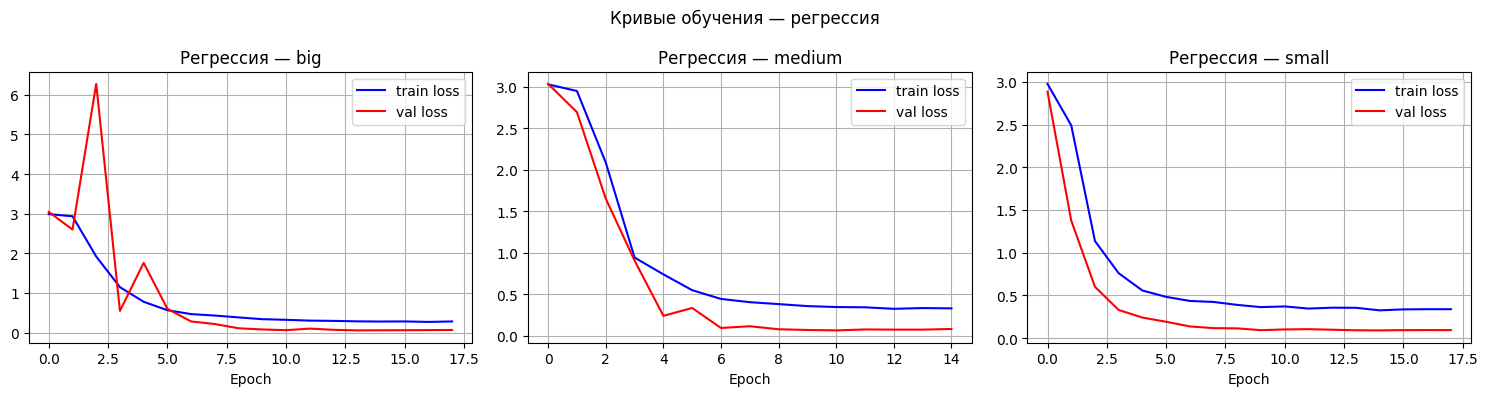

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, ['big', 'medium', 'small']):
    tr = trainers_sz[name]
    ax.plot(tr.tl, 'b', label='train loss')
    ax.plot(tr.vl, 'r', label='val loss')
    ax.set_title(f'Регрессия — {name}')
    ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(True)
plt.suptitle('Кривые обучения — регрессия')
plt.tight_layout(); plt.show()


## 3b. Регрессия на реальных данных — California Housing

**Датасет:** `sklearn.fetch_california_housing` — 20 640 домов, 8 признаков, цель — медианная цена.  
**Лосс:** MSE  
**Метрики:** RMSE + R² на тест-сете  
**Чекпоинт:** `checkpoints/reg_california.npz`  
**Режим:** компактный конфиг для более быстрого запуска

  Dataset=California Housing | Train=15480, Val=2580, Test=2580
  ep  4/36 lr=9.9e-04 | tr=0.3839 vl=0.3990 | metric=0.6266
  ep  8/36 lr=9.3e-04 | tr=0.3291 vl=0.3938 | metric=0.6231
  ep 12/36 lr=8.0e-04 | tr=0.3042 vl=0.3735 | metric=0.6070
  early stop @ ep13

  California Housing — test RMSE=0.5749  R²=0.6588
  Чекпоинт сохранён: checkpoints/reg_california.npz


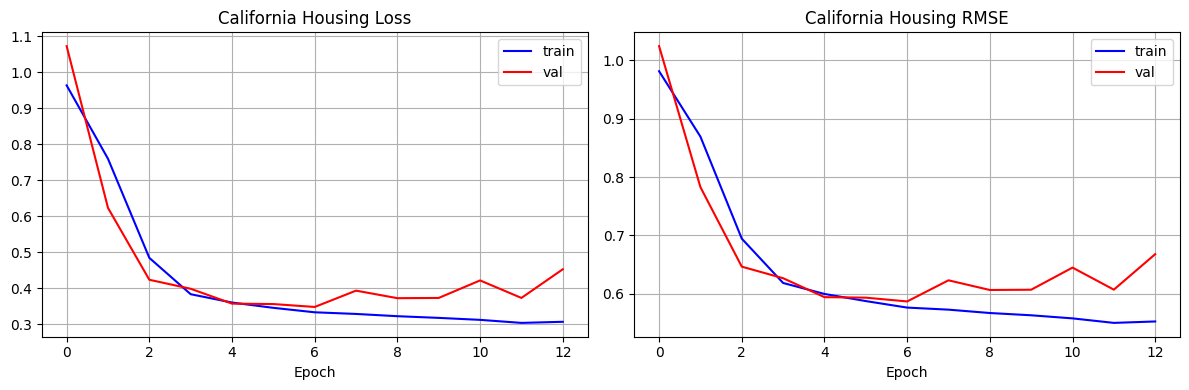

In [7]:
CKPT_DIR = pathlib.Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)

try:
    ch = fetch_california_housing(download_if_missing=False)
    dataset_name = "California Housing"
    ckpt_path = CKPT_DIR / "reg_california.npz"
    X_ch = ch.data.astype(np.float32)
    y_ch = ch.target.astype(np.float32).reshape(-1, 1)
except Exception as e:
    print(f"  California Housing недоступен ({e}), используем load_diabetes.")
    ch = load_diabetes()
    dataset_name = "Diabetes"
    ckpt_path = CKPT_DIR / "reg_diabetes.npz"
    X_ch = ch.data.astype(np.float32)
    y_ch = ch.target.astype(np.float32).reshape(-1, 1)

sc_x_ch, sc_y_ch = StandardScaler(), StandardScaler()
X_ch = sc_x_ch.fit_transform(X_ch).astype(np.float32)
y_ch = sc_y_ch.fit_transform(y_ch).astype(np.float32)

X_ch_tr, X_ch_tmp, y_ch_tr, y_ch_tmp = train_test_split(X_ch, y_ch, test_size=0.25, random_state=3)
X_ch_va, X_ch_te, y_ch_va, y_ch_te = train_test_split(X_ch_tmp, y_ch_tmp, test_size=0.5, random_state=3)
print(f"  Dataset={dataset_name} | Train={X_ch_tr.shape[0]}, Val={X_ch_va.shape[0]}, Test={X_ch_te.shape[0]}")

def build_reg_ch(hs, Act=ReLU):
    m = Sequential()
    d = X_ch.shape[1]
    for h in hs:
        m.add(Linear(d, h)).add(BatchNormalization(0.9)).add(ChannelwiseScaling(h))
        m.add(Act()).add(Dropout(0.2))
        d = h
    return m.add(Linear(d, 1))

ch_epochs = 36
ch_bs = 512
ch_patience = 6

np.random.seed(42)
mdl_ch = build_reg_ch([96, 48])
tr_ch = Trainer(mdl_ch, MSECriterion(), Adam(mdl_ch, lr=1e-3), rmse, cosine_lr,
                checkpoint_path=ckpt_path)
tr_ch.fit(X_ch_tr, y_ch_tr, X_ch_va, y_ch_va,
          epochs=ch_epochs, bs=ch_bs, patience=ch_patience,
          warmup=2, lr=1e-3, verbose=True)

mdl_ch.evaluate()
pred_ch = mdl_ch.forward(X_ch_te)
r2_ch = r2_score(pred_ch, y_ch_te)
print(f"\n  {dataset_name} — test RMSE={rmse(pred_ch, y_ch_te):.4f}  R²={r2_ch:.4f}")
print(f"  Чекпоинт сохранён: {ckpt_path}")
if dataset_name == "California Housing" and r2_ch > 0.7:
    print("  хороший результат для California Housing")
elif dataset_name != "California Housing" and r2_ch > 0.3:
    print("  для fallback-датасета результат выглядит адекватно")

tr_ch.plot(dataset_name, "RMSE")


## 4. Многоклассовая классификация — CNN на MNIST (или load_digits 8×8 как fallback)

**Датасет:** `torchvision.datasets.MNIST` если доступен интернет, иначе `sklearn.load_digits` — аналогичная задача классификации рукописных цифр 0–9.  
**Архитектура:** Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → Flatten → Linear → Dropout → Linear → LogSoftMax  
**Лосс:** ClassNLLCriterion (negative log-likelihood)  
**Метрика:** Accuracy


In [8]:
def try_load_mnist():
    """Пытается быстро взять MNIST из openml/cache. Если не выходит, используем load_digits."""
    try:
        import socket
        from sklearn.datasets import fetch_openml
        prev_timeout = socket.getdefaulttimeout()
        socket.setdefaulttimeout(5)
        try:
            print("  Пробуем загрузить MNIST из openml/cache...")
            mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
        finally:
            socket.setdefaulttimeout(prev_timeout)
        X = (mnist.data / 255.).astype(np.float32).reshape(-1, 1, 28, 28)
        y = mnist.target.astype(int)
        print(f"  MNIST загружен: {X.shape}")
        return X, y
    except Exception as e:
        print(f"  MNIST недоступен ({e}), используем load_digits.")
        return None

mnist_data = try_load_mnist()

if mnist_data is not None:
    # Для самописного Conv2d полный MNIST + много эпох слишком медленный,
    # поэтому берём компактный поднабор и более короткое обучение.
    Xd, yd = mnist_data
    idx = np.random.RandomState(42).permutation(len(yd))
    Xd, yd = Xd[idx[:6000]], yd[idx[:6000]]
    IMG_SIZE = 28
    dataset_name = 'MNIST'
    cls_lr = 8e-4
    cls_bs = 256
    cls_epochs = 12
    cls_patience = 4
    cls_warmup = 2
    cls_dropout = 0.2
else:
    # Fallback
    from sklearn.datasets import load_digits
    dig = load_digits()
    Xd = (dig.data / 16.).astype(np.float32).reshape(-1, 1, 8, 8)
    yd = dig.target
    IMG_SIZE = 8
    dataset_name = 'Digits'
    cls_lr = 1e-3
    cls_bs = 256
    cls_epochs = 16
    cls_patience = 5
    cls_warmup = 2
    cls_dropout = 0.2
    print(f"  load_digits: {Xd.shape}")

Xdt, Xdtmp, ydt, ydtmp = train_test_split(Xd, yd, test_size=0.25, random_state=42, stratify=yd)
Xdv, Xdte, ydv, ydte   = train_test_split(Xdtmp, ydtmp, test_size=0.5, random_state=42, stratify=ydtmp)

def oh(y, n=10): o=np.zeros((len(y),n),np.float32); o[np.arange(len(y)),y]=1.; return o
Ydt, Ydv, Ydte = oh(ydt), oh(ydv), oh(ydte)
def acc(p, t): return float((p.argmax(1)==t.argmax(1)).mean())
print(f"  Dataset={dataset_name} | Train={Xdt.shape[0]}, Val={Xdv.shape[0]}, Test={Xdte.shape[0]}, img={IMG_SIZE}×{IMG_SIZE}")
print(f"  Fast config: epochs={cls_epochs}, bs={cls_bs}, lr={cls_lr}")

# два MaxPool(2,2) делят пространственные размеры на 4
# 8×8 → 2×2, 28×28 → 7×7
flat_dim = 32 * (IMG_SIZE // 4) * (IMG_SIZE // 4)
assert flat_dim > 0, f"flat_dim должен быть > 0, получили {flat_dim}"

np.random.seed(42)
cnn = Sequential()
cnn.add(Conv2d(1, 16, 3, padding=1)).add(ReLU())
cnn.add(MaxPool2d(2, 2))
cnn.add(Conv2d(16, 32, 3, padding=1)).add(ReLU())
cnn.add(MaxPool2d(2, 2))
cnn.add(Flatten(1, -1))  
cnn.add(Linear(flat_dim, 64)).add(ReLU()).add(Dropout(cls_dropout))
cnn.add(Linear(64, 10)).add(LogSoftMax())

tr_cnn = Trainer(cnn, ClassNLLCriterion(), Adam(cnn, lr=cls_lr), acc, cosine_lr)
tr_cnn.fit(Xdt, Ydt, Xdv, Ydv,
           epochs=cls_epochs, bs=cls_bs, patience=cls_patience,
           warmup=cls_warmup, lr=cls_lr, verbose=True)

cnn.evaluate()
test_acc = acc(cnn.forward(Xdte), Ydte)
print(f"\n  Test Accuracy: {test_acc:.4f}")
if test_acc < 0.65:
    print(" если нужен результат выше, можно поднять epochs только для этой секции")


  Пробуем загрузить MNIST из openml/cache...
  MNIST загружен: (70000, 1, 28, 28)
  Dataset=MNIST | Train=4500, Val=750, Test=750, img=28×28
  Fast config: epochs=12, bs=256, lr=0.0008
  ep  1/12 lr=4.0e-04 | tr=2.2586 vl=2.1875 | metric=0.4145
  ep  2/12 lr=8.0e-04 | tr=1.9180 vl=1.4838 | metric=0.6577
  ep  3/12 lr=7.8e-04 | tr=1.1288 vl=0.7470 | metric=0.7925
  ep  4/12 lr=7.2e-04 | tr=0.6847 vl=0.5296 | metric=0.8495
  ep  5/12 lr=6.4e-04 | tr=0.5344 vl=0.4402 | metric=0.8802
  ep  6/12 lr=5.2e-04 | tr=0.4431 vl=0.3843 | metric=0.8949
  ep  7/12 lr=4.0e-04 | tr=0.4020 vl=0.3596 | metric=0.9002
  ep  8/12 lr=2.8e-04 | tr=0.3705 vl=0.3410 | metric=0.9057
  ep  9/12 lr=1.7e-04 | tr=0.3551 vl=0.3276 | metric=0.9015
  ep 10/12 lr=7.7e-05 | tr=0.3464 vl=0.3221 | metric=0.9108
  ep 11/12 lr=2.1e-05 | tr=0.3361 vl=0.3207 | metric=0.9135
  ep 12/12 lr=1.0e-06 | tr=0.3393 vl=0.3207 | metric=0.9135

  Test Accuracy: 0.9187


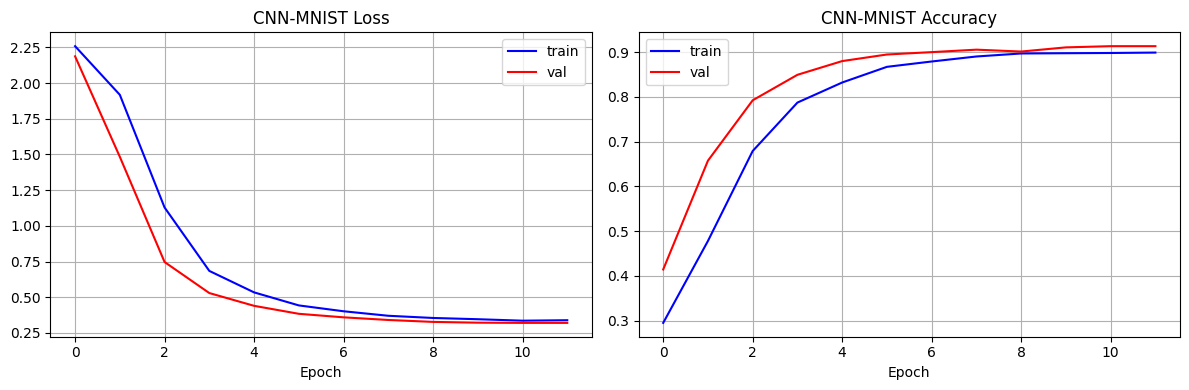

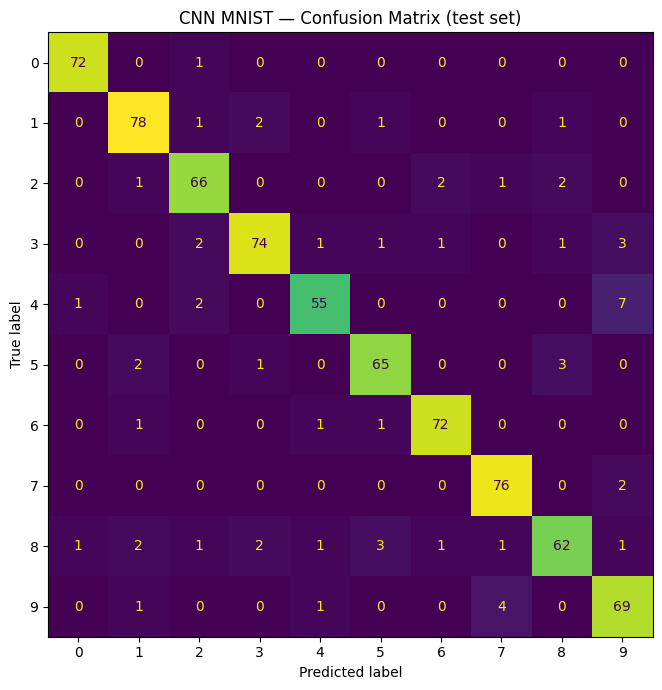

In [9]:
tr_cnn.plot(f"CNN-{dataset_name}","Accuracy"); plt.show()
cnn.evaluate()
y_pred = cnn.forward(Xdte).argmax(1)
cm = confusion_matrix(ydte, y_pred)
fig, ax = plt.subplots(figsize=(8,7))
ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
ax.set_title(f'CNN {dataset_name} — Confusion Matrix (test set)')
plt.tight_layout(); plt.show()

## 5. Свёрточный Автоэнкодер

**Идея:** небольшой convolutional autoencoder для реконструкции изображений.  
**Режим работы:** конфиг подбирается по датасету, чтобы секция не была слишком медленной на самописных свёртках.  
**Encoder/Decoder:** Conv → ELU → Conv → Flatten → Linear bottleneck → Linear → Reshape → Upsample → Conv → Upsample → Conv → Sigmoid  
**Лосс:** MSE4D (pixel-level reconstruction)  
**Метрика:** MSE (чем меньше, тем лучше)

In [10]:
# Архитектура адаптируется под IMG_SIZE (8×8 или 28×28)
# Для самописных свёрток автоэнкодер тоже может быть медленным,
# поэтому уменьшаем и модель, и число объектов, и число эпох.
if IMG_SIZE == 28:
    ae_dataset_name = 'MNIST'
    ae_train = Xdt[:min(len(Xdt), 2000)]
    ae_val = Xdv[:min(len(Xdv), 400)]
    ae_test = Xdte[:min(len(Xdte), 400)]
    ae_c1, ae_c2 = 8, 16
    ae_hidden = 48
    LATENT = 12
    ae_dropout = 0.05
    ae_lr = 8e-4
    ae_bs = 256
    ae_epochs = 8
    ae_patience = 3
    ae_warmup = 2
else:
    ae_dataset_name = 'Digits'
    ae_train = Xdt[:min(len(Xdt), 800)]
    ae_val = Xdv[:min(len(Xdv), 150)]
    ae_test = Xdte[:min(len(Xdte), 150)]
    ae_c1, ae_c2 = 12, 24
    ae_hidden = 48
    LATENT = 12
    ae_dropout = 0.05
    ae_lr = 1.2e-3
    ae_bs = 512
    ae_epochs = 12
    ae_patience = 3
    ae_warmup = 2

spatial = IMG_SIZE // 4
ae_flat = ae_c2 * spatial * spatial 

np.random.seed(42)
ae = Sequential()
# encoder: stride=2 вместо MaxPool — сразу уменьшаем и считаем признаки
ae.add(Conv2d(1, ae_c1, 3, stride=2, padding=1)).add(ELU()).add(Dropout(ae_dropout))
ae.add(Conv2d(ae_c1, ae_c2, 3, stride=2, padding=1)).add(ELU())
ae.add(Flatten(1, -1))
ae.add(Linear(ae_flat, ae_hidden)).add(BatchNormalization(0.9)).add(ChannelwiseScaling(ae_hidden)).add(ELU())
ae.add(Linear(ae_hidden, LATENT))
# decoder: сначала FC разворачиваем до нужного размера, потом upsample + conv
ae.add(Linear(LATENT, ae_hidden)).add(ELU())
ae.add(Linear(ae_hidden, ae_flat)).add(ReLU())
ae.add(Reshape(ae_c2, spatial, spatial))
ae.add(Upsample2d(2))
ae.add(Conv2d(ae_c2, ae_c1, 3, padding=1)).add(ELU())
ae.add(Upsample2d(2))
ae.add(Conv2d(ae_c1, 1, 3, padding=1)).add(Sigmoid())

def mse4d(p, t): return float(np.mean((p - t) ** 2))

CKPT_DIR = pathlib.Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
print(f"  Dataset={ae_dataset_name} | Train={ae_train.shape[0]}, Val={ae_val.shape[0]}, Test={ae_test.shape[0]}")
print(f"  Fast config: epochs={ae_epochs}, bs={ae_bs}, lr={ae_lr}, channels=({ae_c1},{ae_c2}), latent={LATENT}")

opt_ae = Adam(ae, lr=ae_lr, wd=1e-5)
tr_ae  = Trainer(ae, MSE4D(), opt_ae, mse4d, cosine_lr,
                 checkpoint_path=CKPT_DIR/"autoencoder.npz")
tr_ae.fit(ae_train, ae_train, ae_val, ae_val,
          epochs=ae_epochs, bs=ae_bs, patience=ae_patience,
          warmup=ae_warmup, lr=ae_lr, verbose=True)

ae.evaluate()
pred_ae = ae.forward(ae_test)
mse_val = mse4d(pred_ae, ae_test)
psnr_db = 10.0 * np.log10(1.0 / max(mse_val, 1e-12))


  Dataset=MNIST | Train=2000, Val=400, Test=400
  Fast config: epochs=8, bs=256, lr=0.0008, channels=(8,16), latent=12
  ep  1/8 lr=4.0e-04 | tr=0.2343 vl=0.2282 | metric=0.2282
  ep  2/8 lr=8.0e-04 | tr=0.2158 vl=0.2007 | metric=0.2007
  ep  3/8 lr=7.5e-04 | tr=0.1800 vl=0.1600 | metric=0.1600
  ep  4/8 lr=6.0e-04 | tr=0.1374 vl=0.1210 | metric=0.1210
  ep  5/8 lr=4.0e-04 | tr=0.1093 vl=0.1020 | metric=0.1020
  ep  6/8 lr=2.0e-04 | tr=0.0983 vl=0.0960 | metric=0.0960
  ep  7/8 lr=5.5e-05 | tr=0.0950 vl=0.0947 | metric=0.0947
  ep  8/8 lr=1.0e-06 | tr=0.0942 vl=0.0947 | metric=0.0947


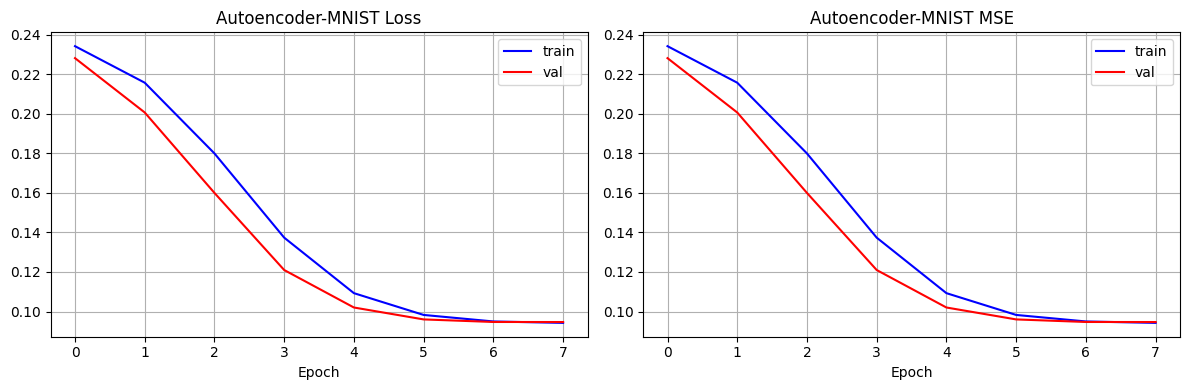

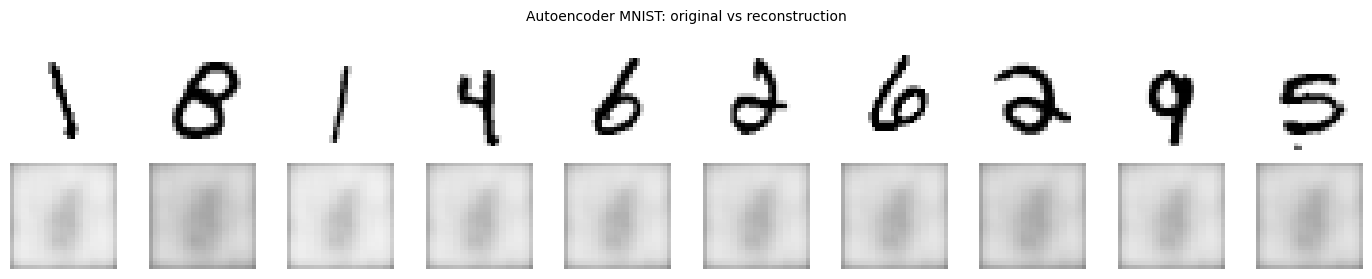

In [11]:
tr_ae.plot(f"Autoencoder-{ae_dataset_name}","MSE")

ae.evaluate()
n = min(10, len(ae_test)); orig = ae_test[:n]; rec = ae.forward(orig)
fig, axes = plt.subplots(2, n, figsize=(n*1.4, 2.8))
for i in range(n):
    axes[0,i].imshow(orig[i,0], cmap='gray_r', vmin=0, vmax=1); axes[0,i].axis('off')
    axes[1,i].imshow(rec[i,0],  cmap='gray_r', vmin=0, vmax=1); axes[1,i].axis('off')
axes[0,0].set_ylabel('Original', fontsize=8)
axes[1,0].set_ylabel('Recon',    fontsize=8)
plt.suptitle(f'Autoencoder {ae_dataset_name}: original vs reconstruction', fontsize=10)
plt.tight_layout(); plt.show()